# Benchmarking Misc in Rust



# Part 1: Contrast Enhancer



In [1]:
import numpy as np
from skimage import exposure

from tiatoolbox import rust_misc


def rust_contrast_enhancer(
    img: np.ndarray, low_p: int = 2, high_p: int = 98
) -> np.ndarray:
    """Enhance contrast of the input image using intensity adjustment.

    This method uses both image low and high percentiles.

    Args:
        img (:class:`numpy.ndarray`): input image used to obtain tissue mask.
            Image should be uint8.
        low_p (scalar): low percentile of image values to be saturated to 0.
        high_p (scalar): high percentile of image values to be saturated to 255.
            high_p should always be greater than low_p.

    Returns:
        img (:class:`numpy.ndarray`):
            Image (uint8) with contrast enhanced.

    Raises:
        AssertionError: Internal errors due to invalid img type.

    Examples:
        >>> from tiatoolbox import utils
        >>> img = utils.misc.contrast_enhancer(img, low_p=2, high_p=98)

    """
    # check if image is not uint8
    # check if image is not uint8
    dimension_for_rust = 3

    if img.dtype != np.uint8:
        msg = "Image should be uint8."
        raise AssertionError(msg)
    if img.ndim == dimension_for_rust:
        return rust_misc.contrast_enhancer(img, low_p, high_p)
    img_out = img.copy()
    percentiles = np.array(np.percentile(img_out, (low_p, high_p)))
    p_low, p_high = percentiles[0], percentiles[1]
    if p_low >= p_high:
        p_low, p_high = np.min(img_out), np.max(img_out)
    if p_high > p_low:
        img_out = exposure.rescale_intensity(
            img_out,
            in_range=(p_low, p_high),
            out_range=(0.0, 255.0),
        )
    return img_out.astype(np.uint8)

In [2]:
def py_contrast_enhancer(
    img: np.ndarray, low_p: int = 2, high_p: int = 98
) -> np.ndarray:
    """Enhance contrast of the input image using intensity adjustment.

    This method uses both image low and high percentiles.

    Args:
        img (:class:`numpy.ndarray`): input image used to obtain tissue mask.
            Image should be uint8.
        low_p (scalar): low percentile of image values to be saturated to 0.
        high_p (scalar): high percentile of image values to be saturated to 255.
            high_p should always be greater than low_p.

    Returns:
        img (:class:`numpy.ndarray`):
            Image (uint8) with contrast enhanced.

    Raises:
        AssertionError: Internal errors due to invalid img type.

    Examples:
        >>> from tiatoolbox import utils
        >>> img = utils.misc.contrast_enhancer(img, low_p=2, high_p=98)

    """
    # check if image is not uint8
    if img.dtype != np.uint8:
        msg = "Image should be uint8."
        raise AssertionError(msg)
    img_out = img.copy()
    percentiles = np.array(np.percentile(img_out, (low_p, high_p)))
    p_low, p_high = percentiles[0], percentiles[1]
    if p_low >= p_high:
        p_low, p_high = np.min(img_out), np.max(img_out)
    if p_high > p_low:
        img_out = exposure.rescale_intensity(
            img_out,
            in_range=(p_low, p_high),
            out_range=(0.0, 255.0),
        )
    return img_out.astype(np.uint8)

In [3]:
import time

sizeofarray = []
timings = []
i = 1
maxarraysize = 10000
while i <= maxarraysize:
    python_times = np.empty(0)
    rust_times = np.empty(0)
    for _j in range(10):
        rng = np.random.default_rng()
        temp = rng.uniform(0, 255, size=(i, i, 3)).astype(np.uint8)
        start_time = time.time()
        py_contrast_enhancer(temp, 2, 96)
        python_end_time = time.time() - start_time
        python_times = np.append(python_times, python_end_time)
        start_time = time.time()
        rust_contrast_enhancer(temp, 2, 96)
        rust_end_time = time.time() - start_time
        rust_times = np.append(rust_times, rust_end_time)
    sizeofarray.append(i)
    timings.append([np.average(python_times), np.average(rust_times)])
    i *= 10

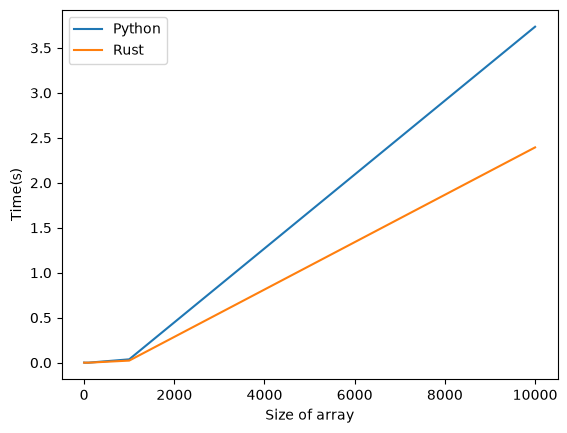

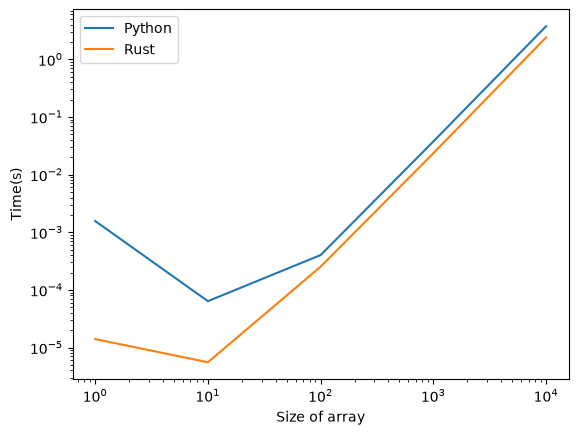

In [4]:
import matplotlib.pyplot as plt

plt.plot(sizeofarray, timings)
plt.xlabel("Size of array")
plt.ylabel("Time(s)")
plt.legend(["Python", "Rust"])
plt.show()
plt.loglog(sizeofarray, timings)
plt.xlabel("Size of array")
plt.ylabel("Time(s)")
plt.legend(["Python", "Rust"])
plt.show()

# Part 2: Patch Predictions As Annotations



In [5]:
from shapely.geometry import Polygon
from tqdm.auto import tqdm

from tiatoolbox.annotation.storage import Annotation


def py_patch_predictions_as_annotations(
    preds: list | np.ndarray,
    keys: list,
    class_dict: dict,
    class_probs: list | np.ndarray,
    patch_coords: list | np.ndarray,
    classes_predicted: list,
    labels: list,
    *,
    verbose: bool = True,
) -> list:
    """Helper function to generate annotation per patch predictions."""
    annotations = []
    tqdm_loop = tqdm(
        patch_coords,
        leave=False,
        desc="Converting outputs to AnnotationStore.",
        disable=not verbose,
    )

    for i, _ in enumerate(tqdm_loop):
        if "probabilities" in keys:
            props = {
                f"prob_{class_dict[j]}": class_probs[i][j] for j in classes_predicted
            }
        else:
            props = {}
        if "labels" in keys:
            props["label"] = class_dict[labels[i]]
        if len(preds) > 0:
            props["type"] = class_dict[preds[i]]
        annotations.append(Annotation(Polygon.from_bounds(*patch_coords[i]), props))

    return annotations

In [6]:
def rust_patch_predictions_as_annotations(
    preds: list | np.ndarray,
    keys: list,
    class_dict: dict,
    class_probs: list | np.ndarray,
    patch_coords: list | np.ndarray,
    classes_predicted: list,
    labels: list,
    *,
    verbose: bool = True,
) -> list:
    """Helper function to generate annotation per patch predictions."""
    tqdm(
        patch_coords,
        leave=False,
        desc="Converting outputs to AnnotationStore.",
        disable=not verbose,
    )
    if len(class_probs) == 0:
        class_probs = np.empty((0, 2))
    if len(patch_coords) == 0:
        patch_coords = np.empty((0, 2))
    return rust_misc.patch_predictions_as_annotations(
        Annotation,
        Polygon,
        preds,
        "labels" in keys,
        "probabilities" in keys,
        class_dict,
        np.array(class_probs).astype("float"),
        np.array(patch_coords).astype("float"),
        classes_predicted,
        labels,
    )

In [7]:
sizeofarray = []
timings = []
timings = []
num_patches = 1
num_classes = 1
max_patches = 1000
while num_patches <= max_patches:
    python_times = np.empty(0)
    rust_times = np.empty(0)
    for _j in range(10):
        rng = np.random.default_rng(42)
        class_probs = rng.random(
            (num_patches, num_classes),
            dtype=np.float64,
        )
        class_probs /= class_probs.sum(axis=1, keepdims=True)
        preds = np.argmax(class_probs, axis=1).astype(np.float64).tolist()
        labels = (
            rng.integers(0, num_classes, size=num_patches).astype(np.int32).tolist()
        )
        x = np.arange(num_patches, dtype=np.float64) * 10
        y = np.zeros(num_patches, dtype=np.float64)
        patch_coords = np.column_stack((x, y, x + 10, y + 10))
        keys = ["predictions", "probabilities", "labels"]
        class_dict = {index: f"class_{index}" for index in range(num_classes)}
        classes_predicted = list(range(num_classes))
        verbose: bool = False
        start_time = time.time()
        py_patch_predictions_as_annotations(
            preds,
            keys,
            class_dict,
            class_probs,
            patch_coords,
            classes_predicted,
            labels,
            verbose=False,
        )
        python_end_time = time.time() - start_time
        python_times = np.append(python_times, python_end_time)
        start_time = time.time()
        rust_patch_predictions_as_annotations(
            preds,
            keys,
            class_dict,
            class_probs,
            patch_coords,
            classes_predicted,
            labels,
            verbose=False,
        )
        rust_end_time = time.time() - start_time
        rust_times = np.append(rust_times, rust_end_time)
    sizeofarray.append(num_patches)
    timings.append([np.average(python_times), np.average(rust_times)])
    num_patches *= 10
    num_classes *= 10

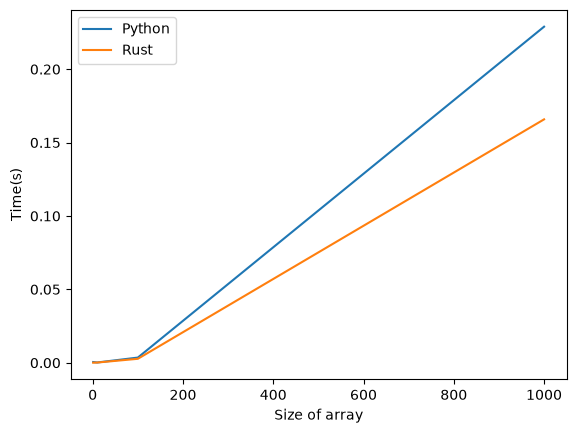

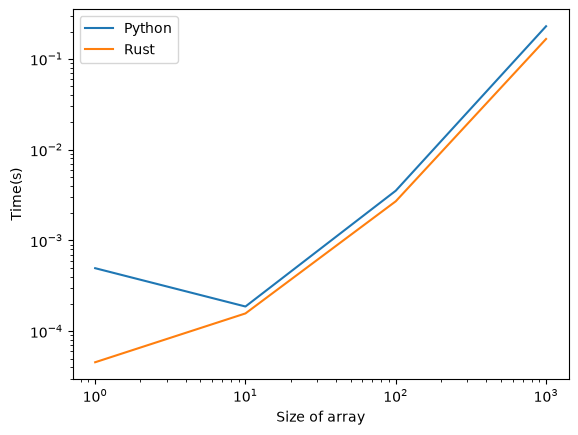

In [8]:
import matplotlib.pyplot as plt

plt.plot(sizeofarray, timings)
plt.xlabel("Size of array")
plt.ylabel("Time(s)")
plt.legend(["Python", "Rust"])
plt.show()
plt.loglog(sizeofarray, timings)
plt.xlabel("Size of array")
plt.ylabel("Time(s)")
plt.legend(["Python", "Rust"])
plt.show()

# Part 3: Patch Predictions As QuPath



In [9]:
import numpy as np
from shapely.geometry import mapping


def py_patch_predictions_as_qupath_json(
    preds: list | np.ndarray,
    class_dict: dict,
    patch_coords: list | np.ndarray,
    *,
    verbose: bool = True,
) -> dict:
    """Helper function to generate QuPath JSON per patch predictions."""
    features = []
    # pick a color for each class based on the class index, using a colormap
    num_classes = len(class_dict)
    cmap = plt.colormaps["tab20"].resampled(num_classes)
    class_colours = {
        class_idx: [
            int(cmap(class_idx)[0] * 255),
            int(cmap(class_idx)[1] * 255),
            int(cmap(class_idx)[2] * 255),
        ]
        for class_idx in class_dict
    }

    tqdm_loop = tqdm(
        range(np.asarray(patch_coords).shape[0]),
        leave=False,
        desc="Converting outputs to QuPath JSON.",
        disable=not verbose,
    )

    for i in tqdm_loop:
        class_idx = int(preds[i])
        class_name = class_dict[class_idx]
        polygon_geo = Polygon.from_bounds(*patch_coords[i])
        polygon_feat = mapping(polygon_geo)

        feature = {
            "type": "Feature",
            "id": f"patch_{i}",
            "geometry": polygon_feat,
            "properties": {
                "classification": {
                    "name": class_name,
                    "color": class_colours[class_idx],
                }
            },
            "objectType": "annotation",
            "name": class_name,
            "class_value": class_idx,
        }

        features.append(feature)

    return {"type": "FeatureCollection", "features": features}

In [10]:
def rust_patch_predictions_as_qupath_json(
    preds: list | np.ndarray,
    class_dict: dict,
    patch_coords: list | np.ndarray,
    *,
    verbose: bool = True,
) -> dict:
    """Helper function to generate QuPath JSON per patch predictions."""
    num_classes = len(class_dict)
    cmap = plt.colormaps["tab20"].resampled(num_classes)
    class_colours = {
        class_idx: [
            int(cmap(class_idx)[0] * 255),
            int(cmap(class_idx)[1] * 255),
            int(cmap(class_idx)[2] * 255),
        ]
        for class_idx in class_dict
    }

    tqdm(
        range(np.asarray(patch_coords).shape[0]),
        leave=False,
        desc="Converting outputs to QuPath JSON.",
        disable=not verbose,
    )
    features = rust_misc.patch_predictions_as_qupath_json(
        class_colours, preds, class_dict, np.array(patch_coords).astype("float")
    )
    return {"type": "FeatureCollection", "features": features}

In [11]:
import time

import matplotlib.pyplot as plt

sizeofarray = []
timings = []
timings = []
num_patches = 1
num_classes = 1
max_patches = 1000
while num_patches <= max_patches:
    python_times = np.empty(0)
    rust_times = np.empty(0)
    for _j in range(10):
        rng = np.random.default_rng(42)
        class_probs = rng.random(
            (num_patches, num_classes),
            dtype=np.float64,
        )
        class_probs /= class_probs.sum(axis=1, keepdims=True)
        preds = np.argmax(class_probs, axis=1).astype(np.float64).tolist()
        x = np.arange(num_patches, dtype=np.float64) * 10
        y = np.zeros(num_patches, dtype=np.float64)
        patch_coords = np.column_stack((x, y, x + 10, y + 10))
        class_dict = {index: f"class_{index}" for index in range(num_classes)}
        classes_predicted = list(range(num_classes))
        verbose: bool = False
        start_time = time.time()
        py_patch_predictions_as_qupath_json(
            preds,
            class_dict,
            patch_coords,
            verbose=False,
        )
        python_end_time = time.time() - start_time
        python_times = np.append(python_times, python_end_time)
        start_time = time.time()
        rust_patch_predictions_as_qupath_json(
            preds,
            class_dict,
            patch_coords,
            verbose=False,
        )
        rust_end_time = time.time() - start_time
        rust_times = np.append(rust_times, rust_end_time)
    sizeofarray.append(num_patches)
    timings.append([np.average(python_times), np.average(rust_times)])
    num_patches *= 10
    num_classes *= 10

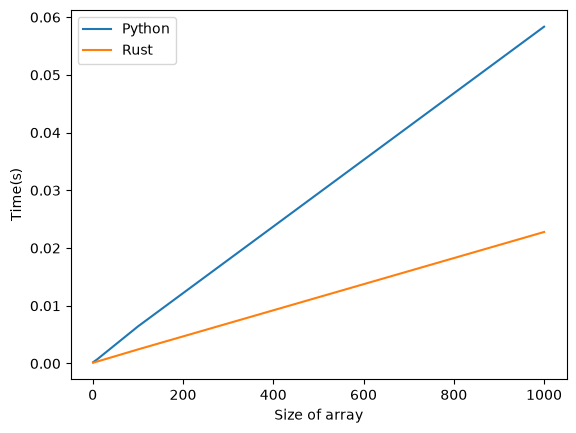

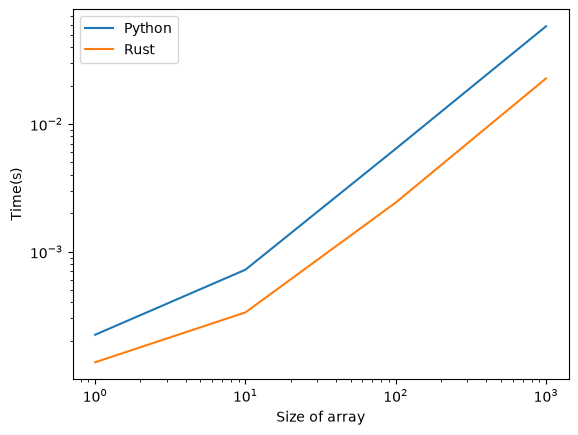

In [12]:
import matplotlib.pyplot as plt

plt.plot(sizeofarray, timings)
plt.xlabel("Size of array")
plt.ylabel("Time(s)")
plt.legend(["Python", "Rust"])
plt.show()
plt.loglog(sizeofarray, timings)
plt.xlabel("Size of array")
plt.ylabel("Time(s)")
plt.legend(["Python", "Rust"])
plt.show()

# Part 4: Json.dump



In [13]:
import json
import time
from pathlib import Path

example_dict = {}
sizeofarray = []
timings = []
i = 1
maxarraysize = 10000
while i <= maxarraysize:
    python_times = np.empty(0)
    rust_times = np.empty(0)
    for j in range(len(example_dict), i):
        example_dict[str(j)] = 1
    for _j in range(10):
        start_time = time.time()
        with Path.open("example.txt", "w") as handle:  # skipcq: PTC-W6004
            json.dump(example_dict, handle)
        python_end_time = time.time() - start_time
        python_times = np.append(python_times, python_end_time)
        start_time = time.time()
        rust_misc.json_dump_python_object("example.txt", example_dict)
        rust_end_time = time.time() - start_time
        rust_times = np.append(rust_times, rust_end_time)
    sizeofarray.append(i)
    timings.append([np.average(python_times), np.average(rust_times)])
    i *= 10

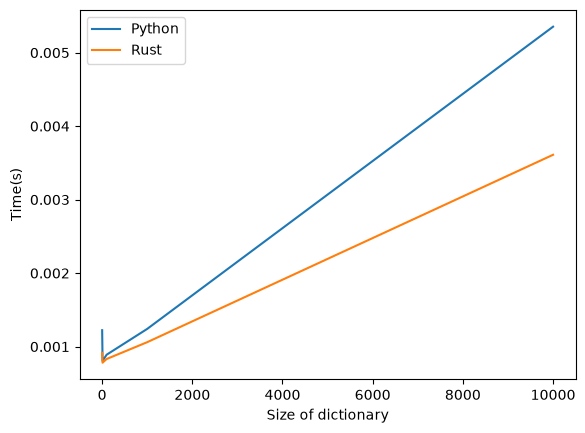

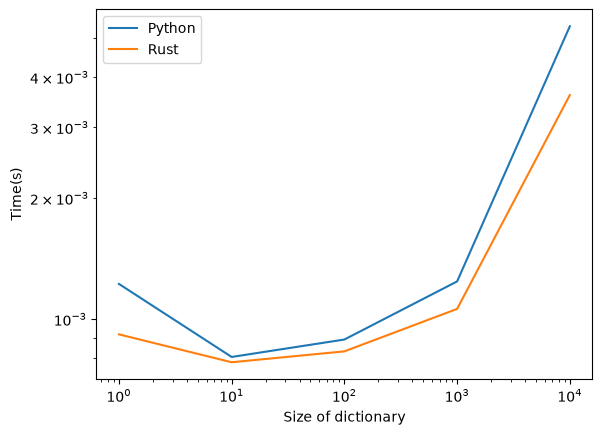

In [14]:
import matplotlib.pyplot as plt

plt.plot(sizeofarray, timings)
plt.xlabel("Size of dictionary")
plt.ylabel("Time(s)")
plt.legend(["Python", "Rust"])
plt.show()
plt.loglog(sizeofarray, timings)
plt.xlabel("Size of dictionary")
plt.ylabel("Time(s)")
plt.legend(["Python", "Rust"])
plt.show()